### 랭스미스
- gmail로그인
- Organizations : Personal 무료한도적용
- 왼쪽메뉴[Tracing] 프로젝트 등록 및 클릭 -> .env설정 및 테스트코드로 연결 검증

*** 연결이 안될때 
- jupyter파일 재시작
- VSCdoe 완전종료 및 재시작

In [ ]:
# !pip --version

pip 26.2.1 from E:\hanwh2609\rag_one\.venv\Lib\site-packages\pip (python 3.12)



In [ ]:
# !pip install -U langchain langchain-openai

In [2]:
from dotenv import load_dotenv
import os

# .env 파일 로드 (override=False가 기본값이므로 시스템 환경변수가 우선순위를 가집니다)
load_dotenv()

# 정상 로드 확인 테스트
print("OpenAI 키:", os.getenv("OPENAI_API_KEY")[:8] + "...")
print("LANGSMITH 키:", os.getenv("LANGSMITH_API_KEY")[:8] + "...")
print("LangSmith 프로젝트:", os.getenv("LANGSMITH_PROJECT"))

OpenAI 키: sk-proj-...
LANGSMITH 키: lsv2_pt_...
LangSmith 프로젝트: proj0913


In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")
response = llm.invoke("대한민국의 수도는 어디인가요?")
print(response.content)

# 랭스미스 Tracing에서 확인하기

대한민국의 수도는 서울입니다.


In [3]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain.agents import create_agent

# 1. Tool 정의
@tool
def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

# 2. 모델 및 에이전트 연결
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
agent = create_agent(model=llm, tools=[get_weather])

# 3. 실행
result = agent.invoke({"messages": [("user", "San Francisco 날씨 어때?")]})
print(result["messages"][-1].content)

# 랭스미스 Tracing에서 확인하기

샌프란시스코의 날씨는 항상 맑습니다!


In [ ]:
# !pip install langchain_teddynote
from langchain_teddynote import logging

In [ ]:
# 랭스미스 추척하기.
logging.langsmith("proj0913", set_enable=True)

In [ ]:
# 랭스미스 추척하지 않기.
logging.langsmith("proj0913", set_enable=False)

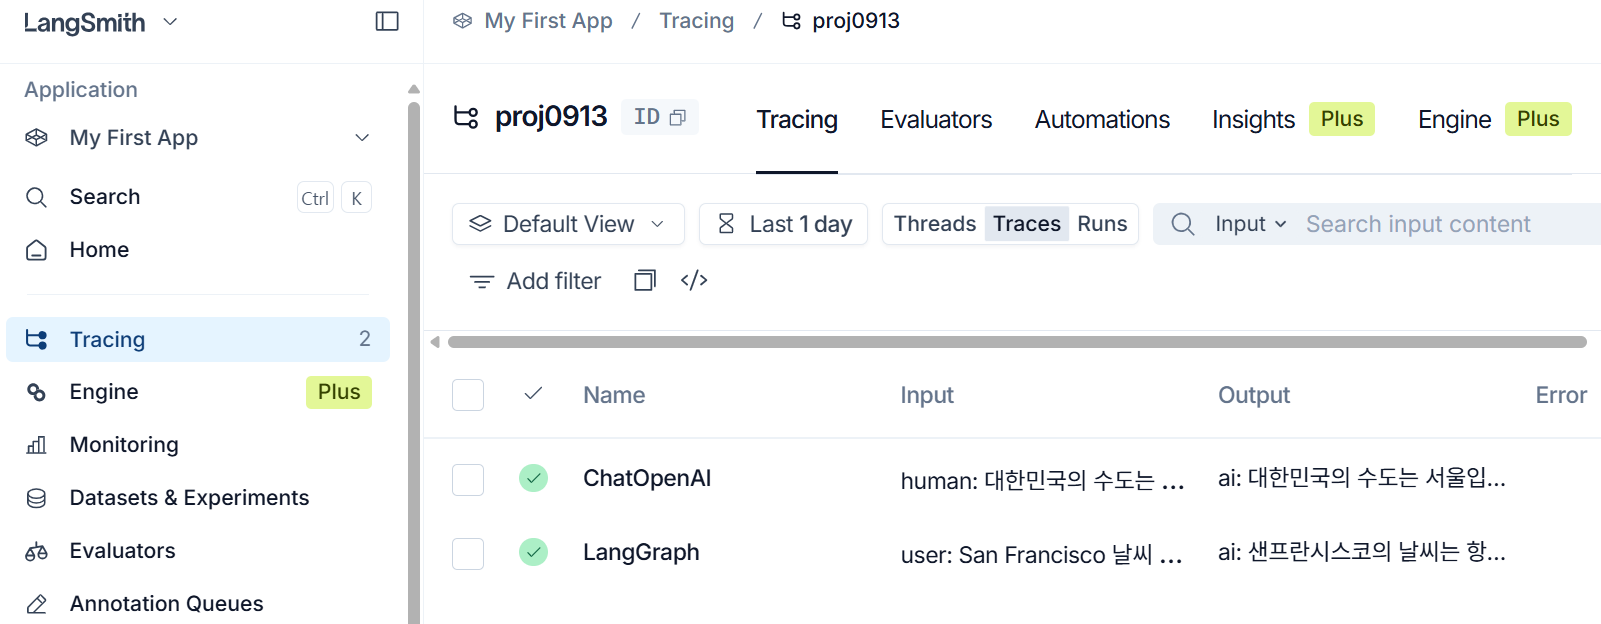